In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv('covid19_tweets.csv')
#convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.date
print(df.head())
print(df.info())

         user_name         user_location  \
0           ᏉᎥ☻լꂅϮ            astroworld   
1    Tom Basile 🇺🇸          New York, NY   
2  Time4fisticuffs      Pewee Valley, KY   
3      ethel mertz  Stuck in the Middle    
4         DIPR-J&K     Jammu and Kashmir   

                                    user_description         user_created  \
0  wednesday addams as a disney princess keepin i...  2017-05-26 05:46:42   
1  Husband, Father, Columnist & Commentator. Auth...  2009-04-16 20:06:23   
2  #Christian #Catholic #Conservative #Reagan #Re...  2009-02-28 18:57:41   
3  #Browns #Indians #ClevelandProud #[]_[] #Cavs ...  2019-03-07 01:45:06   
4  🖊️Official Twitter handle of Department of Inf...  2017-02-12 06:45:15   

   user_followers  user_friends  user_favourites  user_verified        date  \
0             624           950            18775          False  2020-07-25   
1            2253          1677               24           True  2020-07-25   
2            9275          9525    

Basic Cleaning

In [3]:
# Drop duplicate tweets based on 'text'
df.drop_duplicates(subset=['text'], inplace=True)

# Fill missing values
df['user_location'] = df['user_location'].fillna('Unknown')
df['user_description'] = df['user_description'].fillna('No description')
df['hashtags'] = df['hashtags'].fillna('[]')
df['source'] = df['source'].fillna('Unknown')

# Confirm missing values handled
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())


--- Missing Values per Column ---
user_name           0
user_location       0
user_description    0
user_created        0
user_followers      0
user_friends        0
user_favourites     0
user_verified       0
date                0
text                0
hashtags            0
source              0
is_retweet          0
dtype: int64


Basic Descriptive Statistics

In [4]:
print("\n--- Descriptive Statistics for Numeric Columns ---")
print(df.describe())

print("\n--- Verified vs Non-Verified Users ---")
print(df['user_verified'].value_counts())

print("\n--- Top Tweet Sources ---")
print(df['source'].value_counts().head(10))

print("\n--- Top User Locations ---")
print(df['user_location'].value_counts().head(10))



--- Descriptive Statistics for Numeric Columns ---
       user_followers   user_friends  user_favourites
count    1.786830e+05  178683.000000     1.786830e+05
mean     1.089467e+05    2124.233212     1.446683e+04
std      8.418021e+05    9171.425921     4.456527e+04
min      0.000000e+00       0.000000     0.000000e+00
25%      1.730000e+02     149.000000     2.080000e+02
50%      9.950000e+02     543.000000     1.801000e+03
75%      5.286500e+03    1727.000000     9.412500e+03
max      4.944256e+07  497363.000000     2.047197e+06

--- Verified vs Non-Verified Users ---
user_verified
False    155628
True      23055
Name: count, dtype: int64

--- Top Tweet Sources ---
source
Twitter Web App        56846
Twitter for Android    40130
Twitter for iPhone     35458
TweetDeck               8527
Hootsuite Inc.          7317
Twitter for iPad        4334
Buffer                  2728
Sprout Social           1832
Instagram               1759
IFTTT                   1527
Name: count, dtype: int64


Temporal Analysis - Tweets per Day

In [5]:
daily_counts = df.groupby('date').size().reset_index(name='tweet_count')
daily_counts['cumulative'] = daily_counts['tweet_count'].cumsum()

# Estimate a hypothetical “population” of interested users
total_users = 1_000_000
daily_counts['S'] = total_users - daily_counts['cumulative']
daily_counts['I'] = daily_counts['tweet_count']
daily_counts['R'] = daily_counts['cumulative']

print("\n--- Daily Tweet Counts ---")
print(daily_counts.head())



--- Daily Tweet Counts ---
         date  tweet_count  cumulative       S      I      R
0  2020-07-24          295         295  999705    295    295
1  2020-07-25        16858       17153  982847  16858  17153
2  2020-07-26         7480       24633  975367   7480  24633
3  2020-07-27         7480       32113  967887   7480  32113
4  2020-07-28         7486       39599  960401   7486  39599


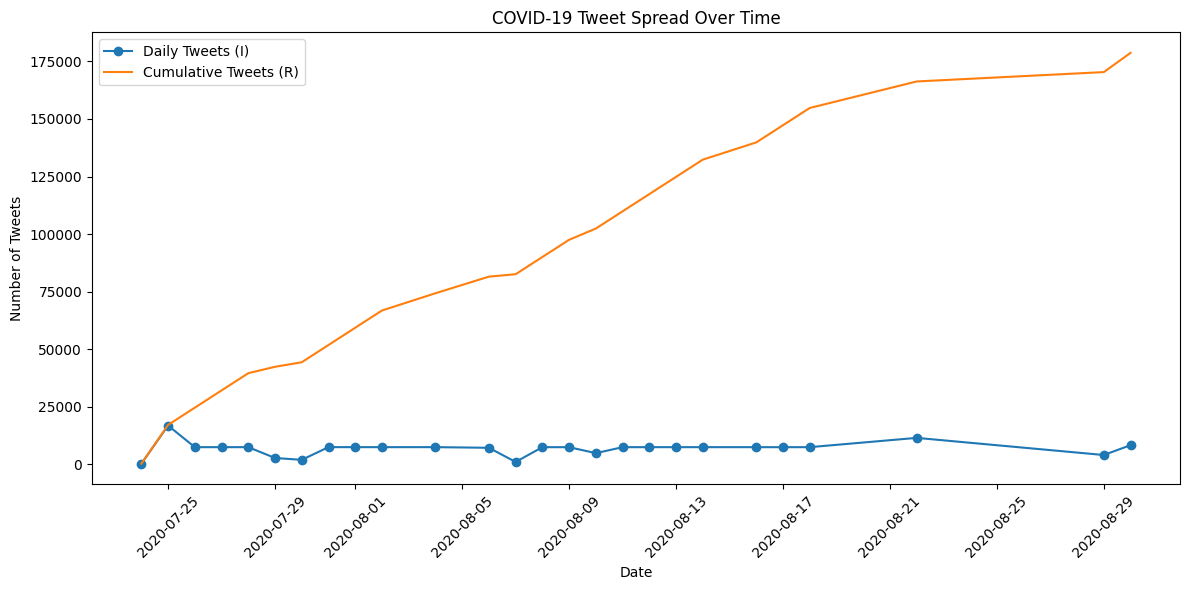

In [6]:
# --- Line Plot of Tweets Over Time ---
plt.figure(figsize=(12,6))
plt.plot(daily_counts['date'], daily_counts['I'], label='Daily Tweets (I)', marker='o')
plt.plot(daily_counts['date'], daily_counts['R'], label='Cumulative Tweets (R)')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('COVID-19 Tweet Spread Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

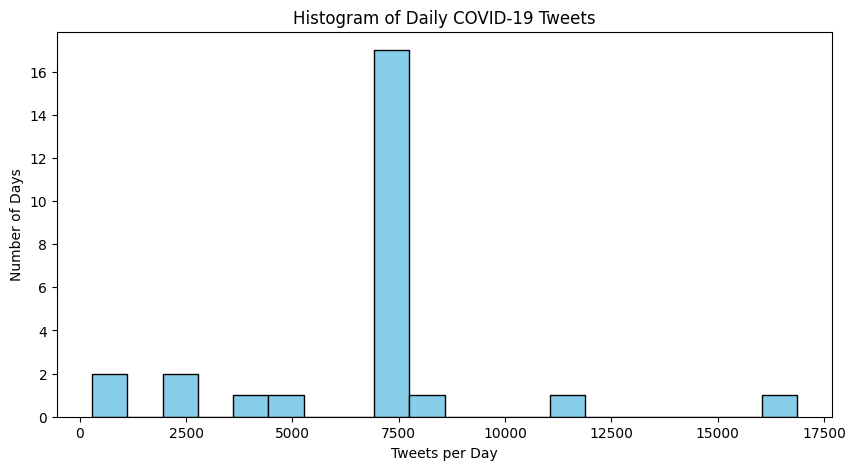

In [7]:
# --- Histogram of Daily Tweet Counts ---
plt.figure(figsize=(10,5))
plt.hist(daily_counts['I'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Tweets per Day')
plt.ylabel('Number of Days')
plt.title('Histogram of Daily COVID-19 Tweets')
plt.show()

Hashtag Analysis


--- Top 10 Hashtags ---
hashtags
COVID19                80111
Covid19                10493
covid19                 9140
coronavirus             7079
Coronavirus             2518
pandemic                1271
India                   1090
CoronavirusPandemic      863
Trump                    830
lockdown                 806
Name: count, dtype: int64


/var/folders/pt/5fxhzqtx7zscq7l481h46sgr0000gn/T/ipykernel_1418/364022857.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hashtags.values, y=top_hashtags.index, palette='viridis')


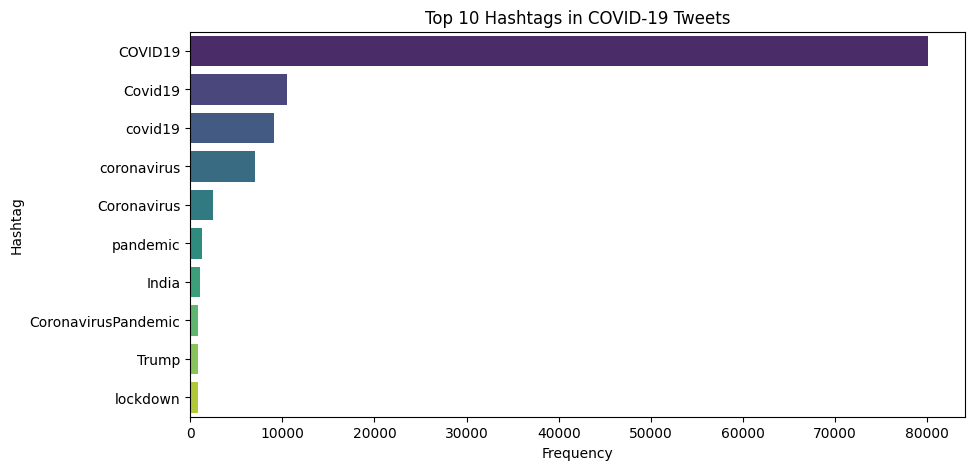

In [8]:
def clean_hashtags(text):
    """
    Cleans a hashtag string like "['COVID19', 'CoronaVirus']"
    into a list of hashtags: ['COVID19', 'CoronaVirus']
    """
    if not isinstance(text, str) or text.strip() == '':
        return []
    # remove brackets and quotes
    text = text.strip("[]").replace("'", "").replace('"', '')
    # split by comma and clean spaces
    return [tag.strip() for tag in text.split(',') if tag.strip() != '']

# Apply the cleaner
hashtags = df['hashtags'].apply(clean_hashtags)
hashtags = hashtags.explode()

# Count top hashtags
top_hashtags = hashtags.value_counts().head(10)
print("\n--- Top 10 Hashtags ---")
print(top_hashtags)

# --- Bar Chart of Top Hashtags ---
plt.figure(figsize=(10,5))
sns.barplot(x=top_hashtags.values, y=top_hashtags.index, palette='viridis')
plt.title('Top 10 Hashtags in COVID-19 Tweets')
plt.xlabel('Frequency')
plt.ylabel('Hashtag')
plt.show()

Source Analysis

/var/folders/pt/5fxhzqtx7zscq7l481h46sgr0000gn/T/ipykernel_1418/565011108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette='mako')


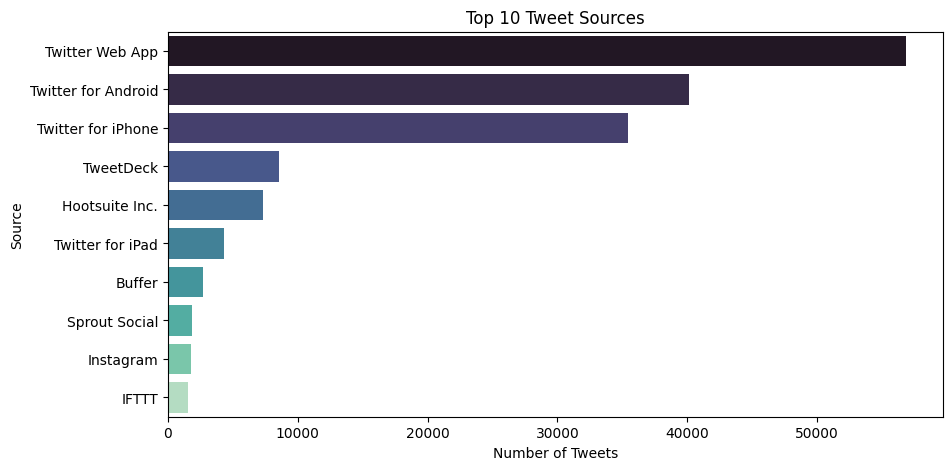

In [12]:
top_sources = df['source'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_sources.values, y=top_sources.index, palette='mako')
plt.title('Top 10 Tweet Sources')
plt.xlabel('Number of Tweets')
plt.ylabel('Source')
plt.show()

/var/folders/pt/5fxhzqtx7zscq7l481h46sgr0000gn/T/ipykernel_1418/565011108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette='mako')


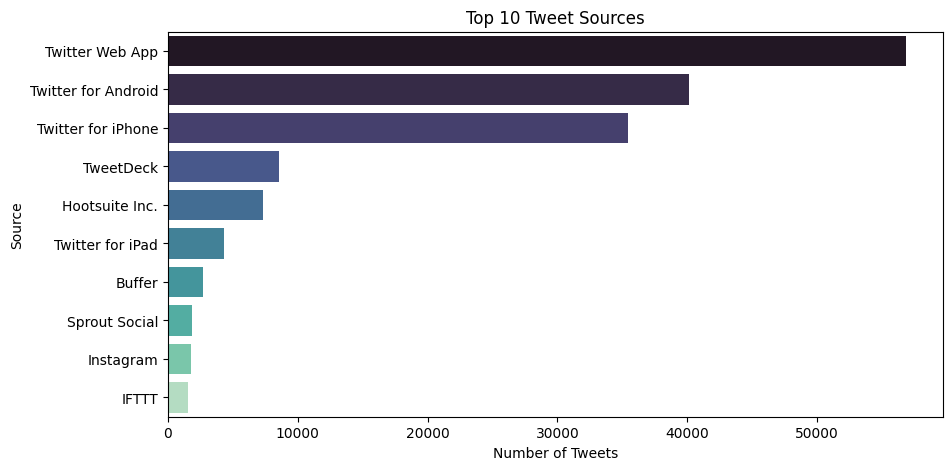

In [13]:
top_sources = df['source'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_sources.values, y=top_sources.index, palette='mako')
plt.title('Top 10 Tweet Sources')
plt.xlabel('Number of Tweets')
plt.ylabel('Source')
plt.show()

Verified vs. Non-Verified Users

/var/folders/pt/5fxhzqtx7zscq7l481h46sgr0000gn/T/ipykernel_1418/2529288721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=verified_counts.index.map({True: 'Verified', False: 'Non-Verified'}),


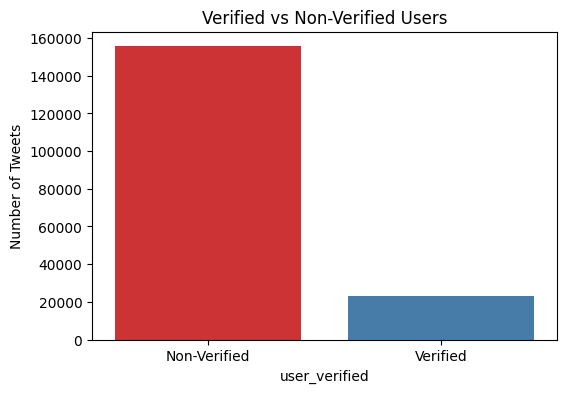

In [19]:
verified_counts = df['user_verified'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=verified_counts.index.map({True: 'Verified', False: 'Non-Verified'}),
            y=verified_counts.values, palette='Set1')
plt.title('Verified vs Non-Verified Users')
plt.ylabel('Number of Tweets')
plt.show()

Save Cleaned Data for Later Stages

In [20]:
df.to_csv('covid19_tweets_clean.csv', index=False)
print("\nCleaned dataset saved as 'covid19_tweets_clean.csv'")


Cleaned dataset saved as 'covid19_tweets_clean.csv'
